# 04 — Model

The single, growing model notebook. Same temporal train/test split throughout (train up to mid-2024, test after) so every version is comparable to every earlier one. One `fit_and_evaluate()` helper is reused for each version — adding a new feature here after `03_features.ipynb` grows means adding one line, not copy-pasting a new fitting cell.

**Reading the metrics, in plain terms:**
- **Test R²** — how much of the price variation the model explains on sales it never saw during training. 0 = no better than guessing the average; 1 = perfect.
- **MdAPE** (median absolute % error) — typical error size. If MdAPE is 15%, half of predictions were off by less than 15% of the true price, half by more.
- **PPE10** — the fraction of predictions that landed within 10% of the true price. The industry standard way to grade an automated valuation model.

In [1]:
import sys
sys.path.insert(0, "..")
from src.config import DATA_INTERIM
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_parquet(DATA_INTERIM / "features.parquet")
df["log_price"] = np.log(df["price"])
df["log_price_adj"] = np.log(df["price_adjusted"])
df["log_area"] = np.log(df["total_floor_area"])
df["log_relsize"] = np.log(df["relative_size"])
df["dist_to_beach_km"] = df["dist_to_beach_m"] / 1000

split_date = pd.Timestamp("2024-07-01")
print(f"{len(df):,} rows loaded")

313,063 rows loaded


## The reusable fit-and-evaluate helper

Takes a target column (raw price or inflation-adjusted price) and a list of feature columns, fits on the training split, scores on the test split, and prints the same set of metrics every time so versions are always directly comparable.

In [2]:
def fit_and_evaluate(feature_cols, label, target_col="log_price_adj"):
    data = df.dropna(subset=feature_cols + [target_col, "date_of_transfer"])
    train = data[data["date_of_transfer"] < split_date]
    test = data[data["date_of_transfer"] >= split_date]

    X_train = sm.add_constant(train[feature_cols])
    model = sm.OLS(train[target_col], X_train).fit()

    X_test = sm.add_constant(test[feature_cols])
    pred_log = model.predict(X_test)
    actual = np.exp(test[target_col])
    pred = np.exp(pred_log)

    ape = (pred - actual).abs() / actual
    mdape = ape.median()
    ppe10 = (ape <= 0.10).mean()
    ss_res = ((test[target_col] - pred_log) ** 2).sum()
    ss_tot = ((test[target_col] - test[target_col].mean()) ** 2).sum()
    test_r2 = 1 - ss_res / ss_tot

    print(f"--- {label} ---")
    print(f"n = {len(train):,} train / {len(test):,} test")
    print(f"Train R2:  {model.rsquared:.3f}")
    print(f"Test R2:   {test_r2:.3f}")
    print(f"Test MdAPE: {mdape:.1%}")
    print(f"Test PPE10: {ppe10:.1%}")
    print()
    return model, pred, {"mdape": mdape, "ppe10": ppe10, "test_r2": test_r2}


## Model versions, in order built

- **v0 — Phase 1 baseline**: floor area only, *no* inflation adjustment. Kept as the fixed reference point everything else is measured against (test R² was ≈0 here — this is what exposed the need for the fix below).
- **v1**: same, but inflation-adjusted. Isolates how much that one fix was worth.
- **v2**: adds `relative_size` (house size vs its 15 nearest neighbours).
- **v3**: adds house type and coastal distance.

In [3]:
built_form_dummies = [c for c in df.columns if c.startswith("type_")]

m0, p0, s0 = fit_and_evaluate(["log_area"], "v0: floor area only (NOT inflation-adjusted)", target_col="log_price")
m1, p1, s1 = fit_and_evaluate(["log_area"], "v1: floor area only (inflation-adjusted)")
m2, p2, s2 = fit_and_evaluate(["log_area", "log_relsize"], "v2: + relative_size")
m3, p3, s3 = fit_and_evaluate(["log_area", "log_relsize", "dist_to_beach_km"] + built_form_dummies, "v3: + house type + coastal distance")

--- v0: floor area only (NOT inflation-adjusted) ---
n = 241,486 train / 31,036 test
Train R2:  0.394
Test R2:   0.028
Test MdAPE: 35.0%
Test PPE10: 11.9%



--- v1: floor area only (inflation-adjusted) ---
n = 241,486 train / 31,036 test
Train R2:  0.412
Test R2:   0.470
Test MdAPE: 23.0%
Test PPE10: 21.5%



--- v2: + relative_size ---
n = 241,486 train / 31,036 test
Train R2:  0.467
Test R2:   0.536
Test MdAPE: 21.0%
Test PPE10: 23.8%



--- v3: + house type + coastal distance ---
n = 241,486 train / 31,036 test
Train R2:  0.597
Test R2:   0.646
Test MdAPE: 16.8%
Test PPE10: 31.4%



## Progress so far

One table, every version, so the next feature added to `03_features.ipynb` has an obvious bar to clear.

In [4]:
summary = pd.DataFrame({
    "version": ["v0: baseline (no HPI fix)", "v1: + HPI adjustment", "v2: + relative_size", "v3: + house type + coastal"],
    "test_r2": [s0["test_r2"], s1["test_r2"], s2["test_r2"], s3["test_r2"]],
    "mdape": [s0["mdape"], s1["mdape"], s2["mdape"], s3["mdape"]],
    "ppe10": [s0["ppe10"], s1["ppe10"], s2["ppe10"], s3["ppe10"]],
}).set_index("version")
print(summary.to_string(formatters={"mdape": "{:.1%}".format, "ppe10": "{:.1%}".format, "test_r2": "{:.3f}".format}))

                           test_r2 mdape ppe10
version                                       
v0: baseline (no HPI fix)    0.028 35.0% 11.9%
v1: + HPI adjustment         0.470 23.0% 21.5%
v2: + relative_size          0.536 21.0% 23.8%
v3: + house type + coastal   0.646 16.8% 31.4%


## What v3 is actually basing predictions on

OLS coefficients on a log-log model translate to "percent change in price per unit change in the feature" — useful for sanity-checking that the model has learned something sensible, not just a black box.

In [5]:
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:          log_price_adj   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                 5.107e+04
Date:                Sat, 08 Aug 2026   Prob (F-statistic):               0.00
Time:                        23:15:55   Log-Likelihood:                -84922.
No. Observations:              241486   AIC:                         1.699e+05
Df Residuals:                  241478   BIC:                         1.699e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  8.3638      0

## Stratified check: does relative_size help most where floor area alone struggles?

The original hypothesis (plan Part 2): on uniform-stock streets, plain floor area stops predicting price at all. `relative_size` was meant to rescue exactly that case. Comparing v1 (no relative_size) against v2 (with it), split by how much floor-area variety each area has.

In [6]:
eval_df = df.dropna(subset=["log_area", "log_relsize", "log_price_adj", "date_of_transfer"])
test_eval = eval_df[eval_df["date_of_transfer"] >= split_date].copy()
test_eval["postcode_district"] = test_eval["postcode"].str.split(" ").str[0]

area_variance = eval_df.assign(postcode_district=eval_df["postcode"].str.split(" ").str[0]) \
    .groupby("postcode_district")["total_floor_area"].std()
test_eval["area_variance_tier"] = pd.qcut(
    test_eval["postcode_district"].map(area_variance), q=3, labels=["low", "medium", "high"]
)

test_eval["pred_v1"] = p1.reindex(test_eval.index)
test_eval["pred_v2"] = p2.reindex(test_eval.index)
test_eval["ape_v1"] = (test_eval["pred_v1"] - test_eval["price_adjusted"]).abs() / test_eval["price_adjusted"]
test_eval["ape_v2"] = (test_eval["pred_v2"] - test_eval["price_adjusted"]).abs() / test_eval["price_adjusted"]

stratified = test_eval.groupby("area_variance_tier", observed=True).agg(
    n=("ape_v1", "size"), v1_mdape=("ape_v1", "median"), v2_mdape=("ape_v2", "median"),
)
stratified["improvement"] = stratified["v1_mdape"] - stratified["v2_mdape"]
print(stratified)

                        n  v1_mdape  v2_mdape  improvement
area_variance_tier                                        
low                 10530  0.221996  0.204527     0.017469
medium              10269  0.237205  0.219594     0.017611
high                10237  0.231406  0.205611     0.025795


---
# v4 — LightGBM

Everything above fits **one equation** to the whole of Sefton: one number
for what a square metre is worth, one number for what being a terrace
costs, applied identically to every house from Southport to Bootle.

LightGBM works differently. It builds a long series of **yes/no question
trees** — "is the floor area above 100 m²? is it detached? is it within
2 km of the beach?" — where each tree is trained specifically on the
mistakes the previous trees made. Hundreds of small trees, each patching
what's still wrong, added together.

**Why that might do better here:**

- It can learn that being near the beach matters a lot in Crosby and not at
  all in Maghull. Our linear model has to pick *one* number for "beach
  effect" and use it everywhere — which is probably why that feature came
  out weak and slightly backwards.
- It doesn't assume every extra square metre adds the same percentage.
  Going 60→90 m² might transform a property; 200→230 m² might barely
  register. Trees split wherever the data says to.

**What we give up:** no tidy equation any more. Section v4c below covers how
we get that understanding back.


## Setting it up

Two pieces of jargon worth knowing before the code:

**Overfitting** — the main risk with a model this flexible. Given enough
trees, it can effectively *memorise* the training sales rather than learn
general patterns, then fall apart on houses it hasn't seen. Like a student
who memorises past exam papers instead of understanding the subject.

**Early stopping** — how we prevent that. We hold back a slice of data the
model doesn't train on, and after every new tree we check whether
performance on that slice is still improving. The moment it stops
improving, we stop adding trees. That's the model telling us it has learned
everything genuinely useful and has started memorising noise.

So the data splits **three** ways, always by date (never randomly — we're
predicting the future, so the test must be genuinely later than the
training):

| Split | Dates | Used for |
|---|---|---|
| Train | up to Jun 2023 | building the trees |
| Validation | Jul 2023 – Jun 2024 | deciding when to stop adding trees |
| **Test** | **Jul 2024 onward** | **the honest score — identical to v0–v3** |

The test set is deliberately unchanged from the earlier models, so any
difference in the final score comes from the model itself, not from a
different exam.


In [7]:
import lightgbm as lgb

# Same features as v3, so this comparison isolates the model change.
v3_features = ["log_area", "log_relsize", "dist_to_beach_km"] + built_form_dummies

lgb_data = df.dropna(subset=v3_features + ["log_price_adj", "date_of_transfer"]).copy()

train_end = pd.Timestamp("2023-07-01")
valid_end = pd.Timestamp("2024-07-01")   # == split_date used by v0-v3

lgb_train = lgb_data[lgb_data["date_of_transfer"] < train_end]
lgb_valid = lgb_data[(lgb_data["date_of_transfer"] >= train_end) & (lgb_data["date_of_transfer"] < valid_end)]
lgb_test  = lgb_data[lgb_data["date_of_transfer"] >= valid_end]

print(f"Train:      {len(lgb_train):,}  (up to {train_end.date()})")
print(f"Validation: {len(lgb_valid):,}  ({train_end.date()} to {valid_end.date()})")
print(f"Test:       {len(lgb_test):,}  (from {valid_end.date()}) <- same test set as v0-v3")


Train:      226,412  (up to 2023-07-01)
Validation: 15,074  (2023-07-01 to 2024-07-01)
Test:       31,036  (from 2024-07-01) <- same test set as v0-v3


## Training

The settings below control how flexible the model is allowed to be. In
plain terms:

- **`learning_rate`** — how big a correction each new tree is allowed to
  make. Small (0.05) means slow, careful improvement; less likely to
  overshoot.
- **`num_leaves`** — how many end-points each tree can have, i.e. how
  detailed a single tree's questioning can get. Higher = more detail but
  more memorisation risk.
- **`min_child_samples`** — the minimum number of real sales that must sit
  behind any conclusion. Stops the model drawing confident rules from three
  houses.
- **`n_estimators=2000`** — the *maximum* number of trees. Early stopping
  will almost certainly halt well before this.

These are sensible starting values, not tuned ones. Tuning them properly
(with a tool called Optuna) is a later step — worth seeing the untuned
result first so we know how much the tuning actually buys.


In [8]:
model_lgb = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

model_lgb.fit(
    lgb_train[v3_features], lgb_train["log_price_adj"],
    eval_set=[(lgb_valid[v3_features], lgb_valid["log_price_adj"])],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

print(f"Stopped after {model_lgb.best_iteration_} trees "
      f"(out of a permitted {model_lgb.n_estimators:,})")
print("If this stopped early, that's the model telling us more trees stopped helping.")


C:\Users\jrbah\Documents (local)\Projects\house_price_prediction\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Stopped after 2000 trees (out of a permitted 2,000)
If this stopped early, that's the model telling us more trees stopped helping.


## How did it score?

In [9]:
def score(pred_log, actual_log, label):
    pred = np.exp(pred_log)
    actual = np.exp(actual_log)
    ape = (pred - actual).abs() / actual
    mdape = ape.median()
    ppe10 = (ape <= 0.10).mean()
    ss_res = ((actual_log - pred_log) ** 2).sum()
    ss_tot = ((actual_log - actual_log.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    print(f"--- {label} ---")
    print(f"Test R2:    {r2:.3f}")
    print(f"Test MdAPE: {mdape:.1%}")
    print(f"Test PPE10: {ppe10:.1%}")
    print()
    return {"test_r2": r2, "mdape": mdape, "ppe10": ppe10}

pred_lgb = pd.Series(model_lgb.predict(lgb_test[v3_features]), index=lgb_test.index)
s4 = score(pred_lgb, lgb_test["log_price_adj"], "v4: LightGBM (same features as v3)")

summary_v4 = pd.DataFrame({
    "version": ["v0: baseline (no HPI fix)", "v1: + HPI adjustment", "v2: + relative_size",
                "v3: + house type + coastal (linear)", "v4: LightGBM, same features"],
    "test_r2": [s0["test_r2"], s1["test_r2"], s2["test_r2"], s3["test_r2"], s4["test_r2"]],
    "mdape":   [s0["mdape"], s1["mdape"], s2["mdape"], s3["mdape"], s4["mdape"]],
    "ppe10":   [s0["ppe10"], s1["ppe10"], s2["ppe10"], s3["ppe10"], s4["ppe10"]],
}).set_index("version")
print(summary_v4.to_string(formatters={"mdape": "{:.1%}".format, "ppe10": "{:.1%}".format, "test_r2": "{:.3f}".format}))


--- v4: LightGBM (same features as v3) ---
Test R2:    0.688
Test MdAPE: 15.4%
Test PPE10: 34.0%

                                    test_r2 mdape ppe10
version                                                
v0: baseline (no HPI fix)             0.028 35.0% 11.9%
v1: + HPI adjustment                  0.470 23.0% 21.5%
v2: + relative_size                   0.536 21.0% 23.8%
v3: + house type + coastal (linear)   0.646 16.8% 31.4%
v4: LightGBM, same features           0.688 15.4% 34.0%


## v4b — letting it use features the linear model couldn't

The comparison above was deliberately handicapped: same features as v3, to
isolate the effect of the model change alone. But tree models can use
things a linear model handles badly or not at all:

- **Raw latitude/longitude.** Meaningless to a linear model (it can only say
  "price rises steadily as you go north"), but trees can carve the map into
  regions — effectively learning neighbourhoods from the data.
- **Room counts** — which the EDA found correlate with price *more* strongly
  than floor area does.
- **Construction age band and tenure** as categories, without needing to
  convert them into numbers first.
- **Missing values.** LightGBM handles gaps natively; the linear model
  required complete rows and silently dropped the rest.

This is where trees are supposed to earn their keep, so it's the fairer
test of whether the approach helps.


In [10]:
extended = ["log_area", "log_relsize", "dist_to_beach_km", "dist_to_marine_lake_m",
            "lat", "lon", "number_habitable_rooms", "number_heated_rooms"]
categorical = ["built_form_clean", "construction_age_band", "tenure", "duration"]

ext_df = df.dropna(subset=["log_price_adj", "date_of_transfer", "log_area"]).copy()

# Room counts arrive from the EPC file as text - convert to numbers.
# ("errors=coerce" turns anything unparseable into a missing value, which
# LightGBM handles natively.)
for c in ["number_habitable_rooms", "number_heated_rooms"]:
    ext_df[c] = pd.to_numeric(ext_df[c], errors="coerce")

for c in categorical:
    ext_df[c] = ext_df[c].astype("category")

ext_features = extended + categorical

ext_train = ext_df[ext_df["date_of_transfer"] < train_end]
ext_valid = ext_df[(ext_df["date_of_transfer"] >= train_end) & (ext_df["date_of_transfer"] < valid_end)]
ext_test  = ext_df[ext_df["date_of_transfer"] >= valid_end]

model_lgb_ext = lgb.LGBMRegressor(
    objective="regression", n_estimators=2000, learning_rate=0.05,
    num_leaves=31, min_child_samples=40, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1,
)
model_lgb_ext.fit(
    ext_train[ext_features], ext_train["log_price_adj"],
    eval_set=[(ext_valid[ext_features], ext_valid["log_price_adj"])],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)
print(f"Stopped after {model_lgb_ext.best_iteration_} trees")
print(f"Test rows: {len(ext_test):,} (more than v4 - missing values no longer force a drop)")
print()

pred_ext = pd.Series(model_lgb_ext.predict(ext_test[ext_features]), index=ext_test.index)
s4b = score(pred_ext, ext_test["log_price_adj"], "v4b: LightGBM, extended features")


C:\Users\jrbah\Documents (local)\Projects\house_price_prediction\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Stopped after 2000 trees
Test rows: 31,036 (more than v4 - missing values no longer force a drop)



--- v4b: LightGBM, extended features ---
Test R2:    0.831
Test MdAPE: 11.1%
Test PPE10: 45.9%



## v4c — getting the transparency back

The trade for accuracy is that there's no longer a tidy equation to read.
Three ways to recover the understanding, in increasing usefulness.

### 1. Which features does it rely on most?

The simple version: how often did the model reach for each feature when
splitting the data? Useful as a broad-strokes check, though it says nothing
about *direction* (whether a feature pushes price up or down).


In [11]:
importance = pd.DataFrame({
    "feature": ext_features,
    "importance": model_lgb_ext.feature_importances_,
}).sort_values("importance", ascending=False)
importance["share"] = importance["importance"] / importance["importance"].sum()
print(importance.to_string(index=False, formatters={"share": "{:.1%}".format}))


               feature  importance share
                   lat        9590 16.0%
      dist_to_beach_km        8150 13.6%
 dist_to_marine_lake_m        7642 12.7%
                   lon        7369 12.3%
              log_area        6816 11.4%
           log_relsize        5940  9.9%
 construction_age_band        5588  9.3%
number_habitable_rooms        2337  3.9%
   number_heated_rooms        2072  3.5%
      built_form_clean        1733  2.9%
                tenure        1414  2.4%
              duration        1349  2.2%


### 2. SHAP — explaining one specific house

This is the one that matters for your actual use case. SHAP breaks a single
prediction into pound-by-pound contributions: it starts from the average
Sefton price and shows how each feature of *this particular house* pushed
the estimate up or down.

That's arguably more useful than the linear model's coefficients ever were.
"Mid-terrace = −61%" was a Sefton-wide average; SHAP tells you what being a
mid-terrace is worth *for this house, in this postcode, at this size*.


In [12]:
import shap

explainer = shap.TreeExplainer(model_lgb_ext)
sample = ext_test.head(500)
shap_values = explainer.shap_values(sample[ext_features])

# Explain one house in pounds rather than log-units, which is what makes
# the numbers readable.
i = 0
house = sample.iloc[i]
base_log = explainer.expected_value
contributions = shap_values[i]

print(f"Explaining: {house['total_floor_area']:.0f} m2 {house['built_form_clean']}, "
      f"postcode {house['postcode']}")
print(f"Actual sold price (in today's money): GBP {house['price_adjusted']:,.0f}")
print(f"Model predicted:                      GBP {np.exp(base_log + contributions.sum()):,.0f}")
print()
print(f"{'Starting point (average Sefton house)':45s} GBP {np.exp(base_log):>10,.0f}")

running = base_log
rows = sorted(zip(ext_features, contributions), key=lambda x: -abs(x[1]))
for feat, contrib in rows:
    before = np.exp(running)
    running += contrib
    after = np.exp(running)
    val = house[feat]
    val_str = f"{val:.1f}" if isinstance(val, (int, float, np.floating)) and not pd.isna(val) else str(val)
    print(f"{feat + ' (' + val_str + ')':45s} {after - before:>+11,.0f}")
print(f"{'':45s} {'':>10}")
print(f"{'PREDICTED':45s} GBP {np.exp(running):>10,.0f}")


C:\Users\jrbah\Documents (local)\Projects\house_price_prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Explaining: 88 m2 Mid-Terrace, postcode L30 9ST
Actual sold price (in today's money): GBP 137,250
Model predicted:                      GBP 142,866

Starting point (average Sefton house)         GBP    217,033
built_form_clean (Mid-Terrace)                    -35,117
log_area (4.5)                                    -12,974
dist_to_marine_lake_m (3177.1)                     -9,370
construction_age_band (England and Wales: 1950-1966)      -7,508
lon (-3.0)                                         -7,063
lat (53.5)                                         -4,237
log_relsize (0.0)                                  -2,852
duration (F)                                       +1,997
tenure (owner-occupied)                            +1,753
dist_to_beach_km (3.3)                             +1,742
number_heated_rooms (5.0)                            -395
number_habitable_rooms (5.0)                         -141
                                                        
PREDICTED                     

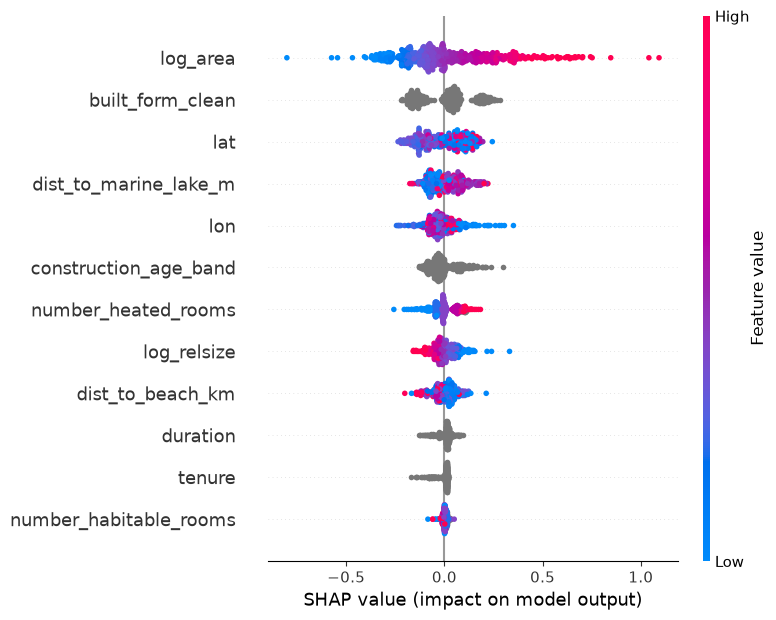

In [13]:
shap.summary_plot(shap_values, sample[ext_features], show=True)


### 3. Sanity checks — has it learned sensible things?

A tidy equation let us eyeball whether the model believed something daft.
With hundreds of trees we check it directly instead: hold everything about
a house constant, vary one feature, and confirm the prediction moves the
way common sense demands.

If any of these fail, something is wrong regardless of how good the test
score looks.


In [14]:
base_house = ext_test[ext_features].iloc[[0]].copy()

print("Check 1 - bigger houses should cost more:")
for area in [60, 80, 100, 130, 170]:
    probe = base_house.copy()
    probe["log_area"] = np.log(area)
    pred = np.exp(model_lgb_ext.predict(probe)[0])
    print(f"  {area:3d} m2 -> GBP {pred:>9,.0f}")

print()
print("Check 2 - detached should beat semi, which should beat terrace:")
for form in ["Detached", "Semi-Detached", "End-Terrace", "Mid-Terrace"]:
    probe = base_house.copy()
    probe["built_form_clean"] = pd.Categorical([form], categories=base_house["built_form_clean"].cat.categories)
    pred = np.exp(model_lgb_ext.predict(probe)[0])
    print(f"  {form:15s} -> GBP {pred:>9,.0f}")


Check 1 - bigger houses should cost more:
   60 m2 -> GBP   123,940
   80 m2 -> GBP   136,627
  100 m2 -> GBP   166,701
  130 m2 -> GBP   212,622
  170 m2 -> GBP   256,477

Check 2 - detached should beat semi, which should beat terrace:
  Detached        -> GBP   241,285
  Semi-Detached   -> GBP   186,375
  End-Terrace     -> GBP   152,943
  Mid-Terrace     -> GBP   142,866


## Keep the linear model too

Not deleting v3. The linear model stays as the readable companion — it can
still say "roughly, terraces go for 60% less than detached across Sefton",
which is quotable in a way a tree ensemble isn't.

More usefully: **when the two models disagree sharply about a specific
house, that disagreement is itself informative** — it usually means the
property is unusual in some way, which is exactly when a valuation deserves
a second look.


In [15]:
common = lgb_test.index.intersection(ext_test.index)
comparison = pd.DataFrame({
    "actual": np.exp(lgb_test.loc[common, "log_price_adj"]),
    "linear_v3": np.exp(m3.predict(sm.add_constant(lgb_test.loc[common, v3_features]))),
    "lightgbm_v4b": np.exp(pred_ext.loc[common]),
})
comparison["disagreement_pct"] = (
    (comparison["lightgbm_v4b"] - comparison["linear_v3"]).abs() / comparison["linear_v3"]
)
print(f"Median disagreement between the two models: {comparison['disagreement_pct'].median():.1%}")
print(f"Cases where they differ by more than 25%:   {(comparison['disagreement_pct'] > 0.25).mean():.1%}")
print()
print("Biggest disagreements - worth a manual look:")
print(comparison.nlargest(5, "disagreement_pct").to_string(
    formatters={c: "{:,.0f}".format for c in ["actual", "linear_v3", "lightgbm_v4b"]}))


Median disagreement between the two models: 14.6%
Cases where they differ by more than 25%:   26.5%

Biggest disagreements - worth a manual look:
          actual linear_v3 lightgbm_v4b  disagreement_pct
287390   761,627   309,453      921,649          1.978319
285907   728,986   315,474      929,071          1.945000
302442   889,559   266,633      743,645          1.789020
286620 1,060,837   352,709      957,903          1.715849
306434   859,831   278,160      727,508          1.615428


---
## v4c — fixing the floor-area wobble

The sanity check above failed, and it's worth fixing before trusting this
on a real purchase. The model predicted:

| Floor area | Predicted |
|---|---|
| 60 m² | £197,225 |
| 80 m² | £212,715 |
| 100 m² | £220,064 |
| **130 m²** | **£219,946**  ← *lower than the 100 m² house* |
| 170 m² | £244,669 |

A 130 m² house coming out slightly cheaper than an otherwise-identical
100 m² one is not a real market effect — it's an artefact. Tree models
build their predictions from step-like splits, and where training data is
thin (few sales at that size in that exact configuration) those steps can
wobble in the wrong direction. The linear model could never do this,
because a straight line with a positive slope is forced to keep rising.

**The fix: a monotonic constraint.** We tell LightGBM outright that price
must never *decrease* as floor area increases. It can still choose how
steeply price rises, and can flatten out — it simply cannot go backwards.
The constraint is enforced while the trees are being built, so it holds for
every possible prediction, not just the ones we happened to test.

**Why only floor area?** Because it's the only relationship here we can
state with total confidence. "Bigger is worth more, all else equal" is
safe. But "more rooms is always better" isn't — a 100 m² house chopped into
6 rooms may be worth *less* than the same space as 4 generous ones. And
we've already seen the beach-distance effect vary by area. Constraining a
relationship that genuinely reverses somewhere would force the model to
learn something false. **Constrain only what you're sure of.**


In [16]:
# One entry per feature, in the same order as ext_features:
#   1 = must increase, -1 = must decrease, 0 = unconstrained
monotone = [
    1,   # log_area               bigger house -> never cheaper
    0,   # log_relsize            ambiguous (we saw its effect flip)
    0,   # dist_to_beach_km       varies by area
    0,   # dist_to_marine_lake_m  varies by area
    0,   # lat
    0,   # lon
    0,   # number_habitable_rooms more rooms in the same space isn't clearly better
    0,   # number_heated_rooms
] + [0] * len(categorical)

assert len(monotone) == len(ext_features), "one constraint per feature required"

model_mono = lgb.LGBMRegressor(
    objective="regression", n_estimators=2000, learning_rate=0.05,
    num_leaves=31, min_child_samples=40, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1,
    monotone_constraints=monotone,
)
model_mono.fit(
    ext_train[ext_features], ext_train["log_price_adj"],
    eval_set=[(ext_valid[ext_features], ext_valid["log_price_adj"])],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)
print(f"Stopped after {model_mono.best_iteration_} trees")
print()

pred_mono = pd.Series(model_mono.predict(ext_test[ext_features]), index=ext_test.index)
s4c = score(pred_mono, ext_test["log_price_adj"], "v4c: LightGBM + monotonic floor area")


C:\Users\jrbah\Documents (local)\Projects\house_price_prediction\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Stopped after 1997 trees



--- v4c: LightGBM + monotonic floor area ---
Test R2:    0.829
Test MdAPE: 11.2%
Test PPE10: 45.3%



### Does the sanity check pass now?

Same probe as before — hold one real house constant, vary only its floor
area. Every step should now be upward.


In [17]:
probe_base = ext_test[ext_features].iloc[[0]].copy()
areas = [50, 60, 70, 80, 90, 100, 115, 130, 150, 170, 200, 250]

preds = []
for area in areas:
    probe = probe_base.copy()
    probe["log_area"] = np.log(area)
    preds.append(np.exp(model_mono.predict(probe)[0]))

print("Floor area -> predicted price (monotonic model):")
violations = 0
for i, (area, pred) in enumerate(zip(areas, preds)):
    flag = ""
    if i > 0 and pred < preds[i - 1]:
        flag = "  <-- DECREASE"
        violations += 1
    print(f"  {area:3d} m2 -> GBP {pred:>9,.0f}{flag}")

print()
print(f"Violations: {violations} (expected 0)")
assert violations == 0, "monotonic constraint did not hold - investigate"
print("PASS - price never decreases as floor area rises.")


Floor area -> predicted price (monotonic model):
   50 m2 -> GBP   125,962
   60 m2 -> GBP   130,907
   70 m2 -> GBP   135,373
   80 m2 -> GBP   139,860
   90 m2 -> GBP   148,246
  100 m2 -> GBP   170,121
  115 m2 -> GBP   218,008
  130 m2 -> GBP   242,350
  150 m2 -> GBP   271,493
  170 m2 -> GBP   293,353
  200 m2 -> GBP   347,338
  250 m2 -> GBP   382,261

Violations: 0 (expected 0)
PASS - price never decreases as floor area rises.


### What did the constraint cost us?

Constraining a model always costs a little accuracy on paper — we've
removed some of its freedom. The question is whether the price is worth
paying for a model that can't produce nonsense.


In [18]:
comparison_mono = pd.DataFrame({
    "version": ["v4b: unconstrained", "v4c: monotonic floor area"],
    "test_r2": [s4b["test_r2"], s4c["test_r2"]],
    "mdape":   [s4b["mdape"], s4c["mdape"]],
    "ppe10":   [s4b["ppe10"], s4c["ppe10"]],
}).set_index("version")
print(comparison_mono.to_string(formatters={
    "mdape": "{:.1%}".format, "ppe10": "{:.1%}".format, "test_r2": "{:.3f}".format}))

delta = s4c["mdape"] - s4b["mdape"]
print()
print(f"Typical error changed by {delta:+.2%} "
      f"({'worse' if delta > 0 else 'better'}) in exchange for guaranteed sensible behaviour.")


                          test_r2 mdape ppe10
version                                      
v4b: unconstrained          0.831 11.1% 45.9%
v4c: monotonic floor area   0.829 11.2% 45.3%

Typical error changed by +0.12% (worse) in exchange for guaranteed sensible behaviour.


---
# Experiment — how wide should the training area be?

Before expanding to six local authorities, a question worth settling:
**does training on a wider area help predictions in Crosby, or dilute
them?**

The intuition cuts both ways:

- **Wider helps** — more sales means more reliable patterns, and tree
  models can *specialise automatically*: they can split on latitude and
  longitude to learn different rules for Crosby than for Bootle. Location
  is already ~25% of what the model relies on, so it clearly does this.
- **Wider hurts** — the model has finite capacity. If Crosby is a small
  slice of the training data, the model may spend its effort on patterns
  that matter elsewhere.

**Sefton is already not one market.** Median prices inside this single
local authority range from £134k (Bootle, L20) to £368k (Formby, L37) —
a 2.7x spread. So the model is *already* pooling across very different
areas, which makes this a live question rather than a theoretical one.

## The test

Two models, evaluated on **the exact same Crosby test properties**:

| Model | Trained on |
|---|---|
| **A — specialist** | L23 Crosby sales only |
| **B — generalist** | all of Sefton (what we have now) |

Same features, same settings, same dates, same test set. The only thing
that differs is how much surrounding area the model was allowed to learn
from — so any difference in score is attributable to that alone.

**If A wins:** specialisation beats volume; expanding to six authorities
would likely hurt, and we should consider narrowing further instead.
**If B wins:** volume wins even across a 2.7x price range; expanding
further will probably help too.


In [19]:
CROSBY = "L23"   # Crosby, Blundellsands, Thornton

scope_df = ext_df.copy()
scope_df["outcode"] = scope_df["postcode"].str.split(" ").str[0]

crosby = scope_df[scope_df["outcode"] == CROSBY]
print(f"Crosby (L23) sales: {len(crosby):,}")
print(f"All Sefton sales:   {len(scope_df):,}  (Crosby is {len(crosby)/len(scope_df):.1%} of it)")

# The test set is the SAME Crosby properties in both cases - post-Jul-2024,
# never seen during training by either model.
crosby_test = crosby[crosby["date_of_transfer"] >= valid_end]
print(f"\nShared Crosby test set: {len(crosby_test):,} sales from {valid_end.date()}")


Crosby (L23) sales: 6,142
All Sefton sales:   272,522  (Crosby is 2.3% of it)

Shared Crosby test set: 746 sales from 2024-07-01


In [ ]:
def train_scoped(train_data, label):
    """Same model settings throughout - only the training area differs."""
    tr = train_data[train_data["date_of_transfer"] < train_end]
    va = train_data[(train_data["date_of_transfer"] >= train_end) &
                    (train_data["date_of_transfer"] < valid_end)]

    m = lgb.LGBMRegressor(
        objective="regression", n_estimators=2000, learning_rate=0.05,
        num_leaves=31, min_child_samples=40, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1, monotone_constraints=monotone,
    )
    m.fit(
        tr[ext_features], tr["log_price_adj"],
        eval_set=[(va[ext_features], va["log_price_adj"])],
        eval_metric="l2",
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
    print(f"{label}: trained on {len(tr):,} sales, validated on {len(va):,}, "
          f"stopped after {m.best_iteration_} trees")
    return m

model_specialist = train_scoped(crosby, "A - specialist (Crosby only)")
model_generalist = train_scoped(scope_df, "B - generalist (all six authorities)")


### Both models, scored on the same Crosby properties


In [ ]:
pred_spec = pd.Series(model_specialist.predict(crosby_test[ext_features]), index=crosby_test.index)
pred_gen  = pd.Series(model_generalist.predict(crosby_test[ext_features]), index=crosby_test.index)

s_spec = score(pred_spec, crosby_test["log_price_adj"], "A - specialist: trained on Crosby only")
s_gen  = score(pred_gen,  crosby_test["log_price_adj"], "B - generalist: trained on all six authorities")

verdict = pd.DataFrame({
    "model": ["A: Crosby only", "B: all six LAs"],
    "train_size": [len(crosby[crosby["date_of_transfer"] < train_end]),
                   len(scope_df[scope_df["date_of_transfer"] < train_end])],
    "test_r2": [s_spec["test_r2"], s_gen["test_r2"]],
    "mdape": [s_spec["mdape"], s_gen["mdape"]],
    "ppe10": [s_spec["ppe10"], s_gen["ppe10"]],
}).set_index("model")
print(verdict.to_string(formatters={
    "mdape": "{:.1%}".format, "ppe10": "{:.1%}".format,
    "test_r2": "{:.3f}".format, "train_size": "{:,}".format}))

print()
diff = s_spec["mdape"] - s_gen["mdape"]
if diff > 0.005:
    print(f"-> GENERALIST WINS by {diff:.1%} on typical error.")
    print("   Volume beats specialisation. Expanding to six authorities will probably help too.")
elif diff < -0.005:
    print(f"-> SPECIALIST WINS by {-diff:.1%} on typical error.")
    print("   Specialisation beats volume. Expanding would likely hurt; consider narrowing instead.")
else:
    print(f"-> TOO CLOSE TO CALL ({diff:+.1%}).")
    print("   Roughly equivalent - expansion is low-risk but may not be worth the effort.")


### Does the generalist actually treat Crosby as its own place?

If pooling works because the model *specialises internally* — carving out
Crosby via latitude/longitude rather than averaging it into Sefton — then
its Crosby predictions should track Crosby's own price level, not Sefton's.

A quick way to see it: compare each model's typical prediction against the
actual Crosby median. A model that had "averaged Crosby away" would predict
noticeably below it, pulled down by Bootle and Litherland.


In [ ]:
actual_median = np.exp(crosby_test["log_price_adj"]).median()
wide_median = np.exp(scope_df[scope_df["date_of_transfer"] >= valid_end]["log_price_adj"]).median()

print(f"Actual Crosby median (test period):     GBP {actual_median:>9,.0f}")
print(f"Actual wide-area median (same period): GBP {wide_median:>9,.0f}")
print()
print(f"Specialist predicted median:            GBP {np.exp(pred_spec).median():>9,.0f}")
print(f"Generalist predicted median:            GBP {np.exp(pred_gen).median():>9,.0f}")
print()
print("If the generalist's median sits near Crosby's rather than Sefton's,")
print("it has learned Crosby is its own market rather than averaging it away.")
